In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands
import ast
import numpy as np

## Type I error

In [ ]:
results = pd.read_csv("simulation_results_20260212_1845.csv")

In [ ]:
# nsim = 50
# n = [100, 150, 200, 250]
# k = [3]
# rho = [0]
# alpha = [0.05]
# marginals = ['gaussian', 'uniform -1 1', 't 5']
# edge_var = [1]
# method = [
#     partial(RVPermutationTest, permutation_type="latent"),
#     LLKRatioTest,
#     QAP,
#     DiffusionCorrelation,
#     partial(CanonicalCorrelationTest, permutation_type="latent"),
# ]

# npermutations = [100]
# metrics = [ComputeAll()]
# approximation = ["F-distr"]

# setup = [
#     (partial(GaussianNetwork, copula_model='gaussian'), MLE_gaussian),
#     (partial(BernoulliNetwork, copula_model='gaussian'), MLE_logistic),
# ]

In [ ]:
results["rho"] = results["args"].apply(
    lambda x: re.search(r"'rho':\s*(\d+\.?\d*)", x).group(1)
)

In [ ]:
results["ComputeAll"] = results["ComputeAll"].apply(
    lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x))
)

results['RelativeFrobeniusNorm_x'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_x', np.nan))
results['RelativeFrobeniusNorm_z'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_z', np.nan))

In [ ]:
results['FalseRejection'] = results['ComputeAll'].apply(lambda x: x.get('FalseRejection', np.nan))
results['TrueRejection'] = results['ComputeAll'].apply(lambda x: x.get('TrueRejection', np.nan))

In [ ]:
results['dgp_name'] = results['dgp'].apply(lambda x: x.split('_')[0])
results['copula_type'] = results['dgp'].apply(lambda x: x.split('_')[1])

In [ ]:
results['marginals'] = results['args'].apply(lambda x: re.search(r"'marginals':\s*['\"]([^'\"]+)['\"]", x).group(1))

### Defining different aggregations

In [ ]:
# based on dgp
results_gaussian = results[(results["dgp_name"] == "GaussianNetwork")].copy() 
results_bernoulli = results[(results["dgp_name"] == "BernoulliNetwork")].copy()

In [ ]:
results_null = results[results['rho'] == '0'].copy()
results_alt_05 = results[results['rho'] == '0.5'].copy()
results_alt_01 = results[results['rho'] == '0.1'].copy()
results_alt_02 = results[results['rho'] == '0.2'].copy()

In [ ]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == "0")].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == "0.5")].copy()
results_alt_001_gaussian = results_gaussian[(results_gaussian["rho"] == "0.01")].copy()
results_alt_01_gaussian = results_gaussian[(results_gaussian["rho"] == "0.1")].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == "0.2")].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0")].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.5")].copy()
results_alt_001_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.01")].copy()
results_alt_01_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.1")].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.2")].copy()

In [ ]:
# neat thing: NaN are ignored
agg_null_gaussian = aggregate_results(results_null_gaussian,
                                      y_axis="FalseRejection",
                                      x_axis="n",
                                      factors=["marginals", "method", "copula_type"])

agg_null_bernoulli = aggregate_results(results_null_bernoulli, 
                             y_axis="FalseRejection",
                             x_axis="n",
                             factors=["marginals", "method", "copula_type"])

# Plots

### Type I error

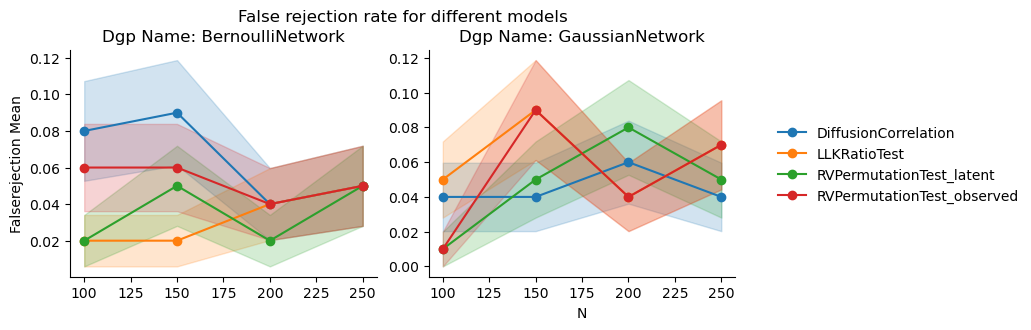

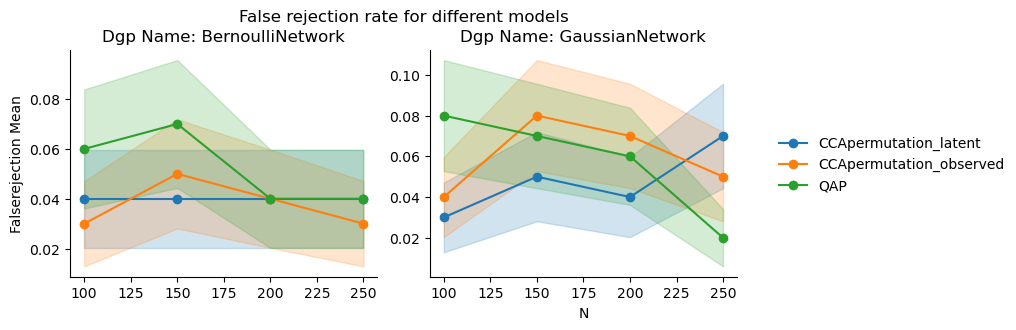

In [ ]:
plot_grid(
    grouped_stats=agg_null_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "dgp_name"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="False rejection rate - Weighted network",
)

In [ ]:
plot_grid(
    grouped_stats=agg_null_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["method", "dgp_name"],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="False rejection rate - binary network",
)

# Power

In [2]:
results = pd.read_csv("simulation_results_20260217_0555.csv")

In [3]:
# nsim = 50
# n = [100, 150, 200, 250]
# k = [3]
# rho = [0.5, 0.2]
# alpha = [0.05]
# marginals = ['gaussian', 'uniform -1 1', 't 5']
# edge_var = [1]
# method = [
#     partial(RVPermutationTest, permutation_type="latent"),
#     LLKRatioTest,
#     QAP,
#     DiffusionCorrelation,
#     partial(CanonicalCorrelationTest, permutation_type="latent"),
# ]

# npermutations = [100]
# metrics = [ComputeAll()]
# approximation = ["F-distr"]

# setup = [
#     (partial(GaussianNetwork, copula_model='gaussian'), MLE_gaussian),
#     (partial(GaussianNetwork, copula_model='clayton'), MLE_gaussian),
#     (partial(GaussianNetwork, copula_model='gumbel'), MLE_gaussian),
#     (partial(GaussianNetwork, copula_model='mixture_uniform', weights=[0.5, 0.5], correlations=[0.98, -0.98]), MLE_gaussian),

#     (partial(BernoulliNetwork, copula_model='gaussian'), MLE_logistic),
#     (partial(BernoulliNetwork, copula_model='clayton'), MLE_logistic),
#     (partial(BernoulliNetwork, copula_model='gumbel'), MLE_logistic),
#     (partial(BernoulliNetwork, copula_model='mixture_uniform', weights=[0.5, 0.5], correlations=[0.98, -0.98]), MLE_logistic),
# ]

In [4]:
results["rho"] = results["args"].apply(
    lambda x: re.search(r"'rho':\s*(\d+\.?\d*)", x).group(1)
)

In [5]:
results["ComputeAll"] = results["ComputeAll"].apply(
    lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x))
)

results['RelativeFrobeniusNorm_x'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_x', np.nan))
results['RelativeFrobeniusNorm_z'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_z', np.nan))

In [6]:
results['FalseRejection'] = results['ComputeAll'].apply(lambda x: x.get('FalseRejection', np.nan))
results['TrueRejection'] = results['ComputeAll'].apply(lambda x: x.get('TrueRejection', np.nan))

In [7]:
results['dgp_name'] = results['dgp'].apply(lambda x: x.split('_')[0])
results['copula_type'] = results['dgp'].apply(lambda x: x.split('_')[1])

In [8]:
results['marginals'] = results['args'].apply(lambda x: re.search(r"'marginals':\s*['\"]([^'\"]+)['\"]", x).group(1))

### Defining different aggregations

In [9]:
# based on dgp
results_gaussian = results[(results["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results[(results["dgp_name"] == "BernoulliNetwork")].copy()

In [10]:
results_null = results[results['rho'] == '0'].copy()
results_alt_05 = results[results['rho'] == '0.5'].copy()
results_alt_01 = results[results['rho'] == '0.1'].copy()
results_alt_02 = results[results['rho'] == '0.2'].copy()

In [11]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == "0")].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == "0.5")].copy()
results_alt_001_gaussian = results_gaussian[(results_gaussian["rho"] == "0.01")].copy()
results_alt_01_gaussian = results_gaussian[(results_gaussian["rho"] == "0.1")].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == "0.2")].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0")].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.5")].copy()
results_alt_001_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.01")].copy()
results_alt_01_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.1")].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0.2")].copy()

In [12]:
# neat thing: NaN are ignored
agg_null = aggregate_results(results_null, 
                             y_axis="RelativeFrobeniusNorm_x",
                             x_axis="n",
                             factors=["marginals", "dgp_name", "copula_type"])

agg_alt_05 = aggregate_results(results_alt_05, 
                               y_axis="RelativeFrobeniusNorm_x",
                               x_axis="n",
                               factors=["marginals", "dgp_name", "copula_type"])

agg_alt_01 = aggregate_results(results_alt_01, 
                               y_axis="RelativeFrobeniusNorm_x",
                               x_axis="n",
                               factors=["marginals", "dgp_name", "copula_type"])

agg_alt_02 = aggregate_results(results_alt_02, 
                               y_axis="RelativeFrobeniusNorm_x",
                               x_axis="n",
                               factors=["marginals", "dgp_name", "copula_type"])

### Power

In [13]:
agg_null_gaussian_ = aggregate_results(results_null_gaussian, 
                                      y_axis="FalseRejection",
                                      x_axis="n",
                                      factors=["marginals", "method", "copula_type"])

agg_alt_05_gaussian = aggregate_results(results_alt_05_gaussian, 
                                        y_axis="TrueRejection",
                                        x_axis="n",
                                        factors=["marginals", "method", "copula_type"])

agg_alt_02_gaussian = aggregate_results(results_alt_02_gaussian, 
                                        y_axis="TrueRejection",
                                        x_axis="n",
                                        factors=["marginals", "method", "copula_type"])

agg_alt_05_bernoulli = aggregate_results(results_alt_05_bernoulli, 
                                         y_axis="TrueRejection",
                                         x_axis="n",
                                         factors=["marginals", "method", "copula_type"])

agg_alt_02_bernoulli = aggregate_results(results_alt_02_bernoulli, 
                                         y_axis="TrueRejection",
                                         x_axis="n",
                                         factors=["marginals", "method", "copula_type"])

In [14]:
copula_group_1 = ['clayton', 'frank', 'gaussian', 'gumbel']

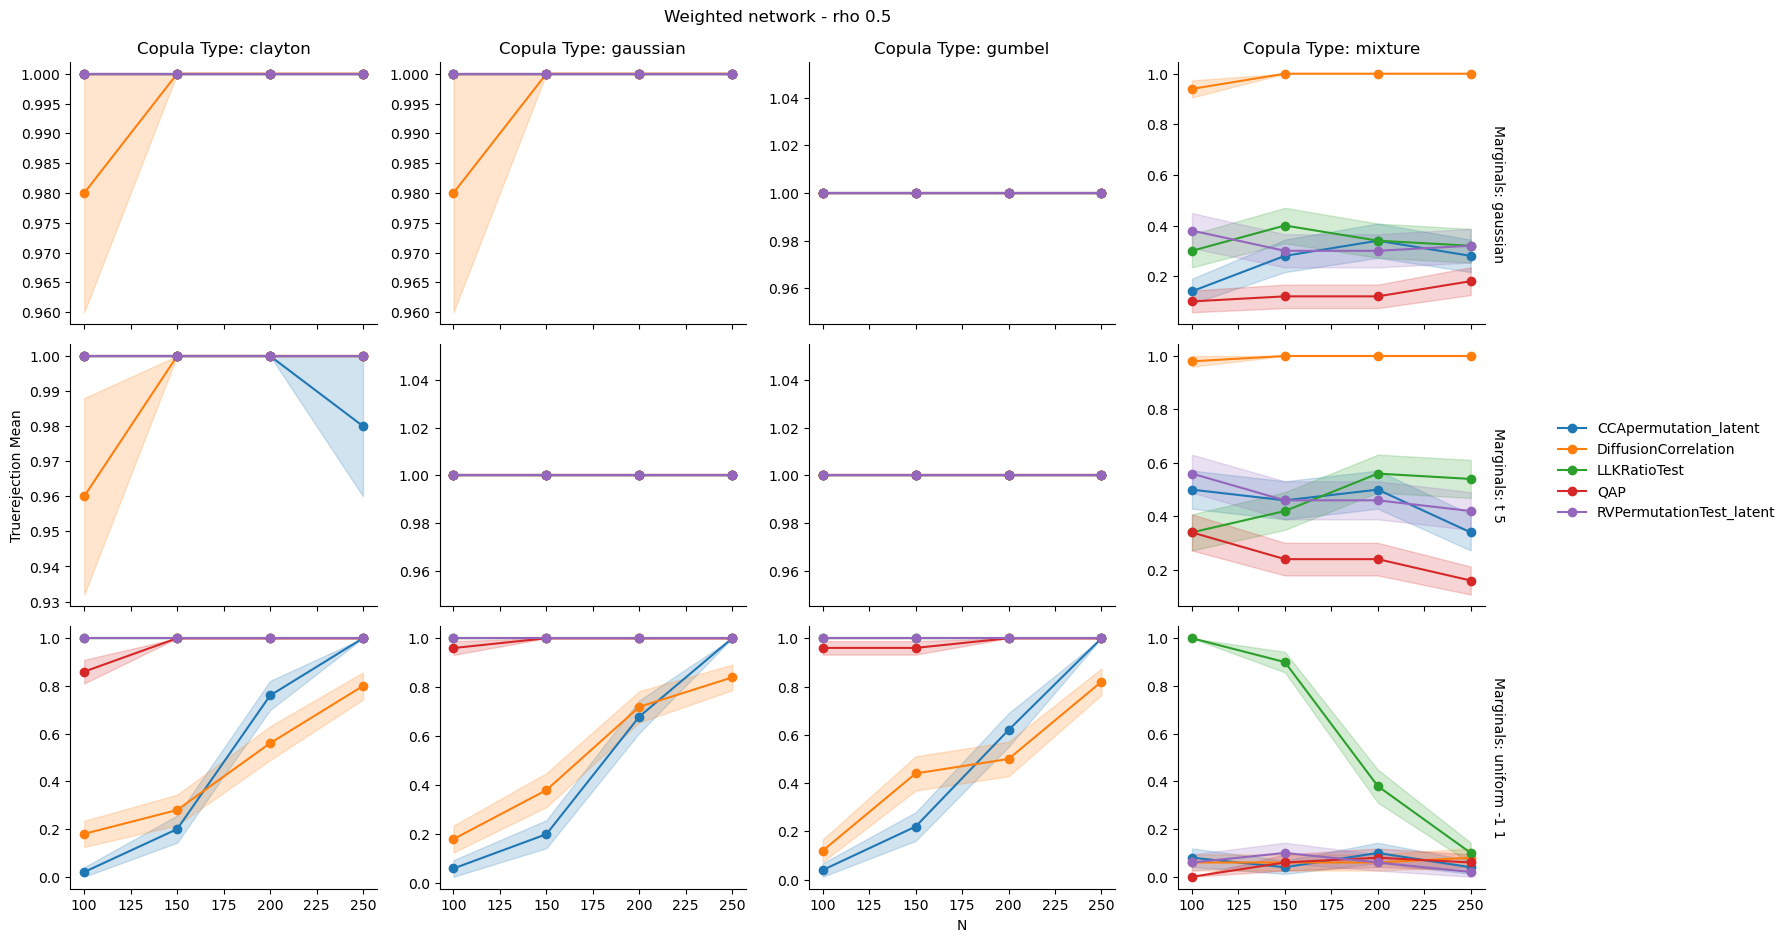

In [20]:
temp = agg_alt_05_gaussian.copy()

plot_grid(
    grouped_stats=agg_alt_05_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.5",
)

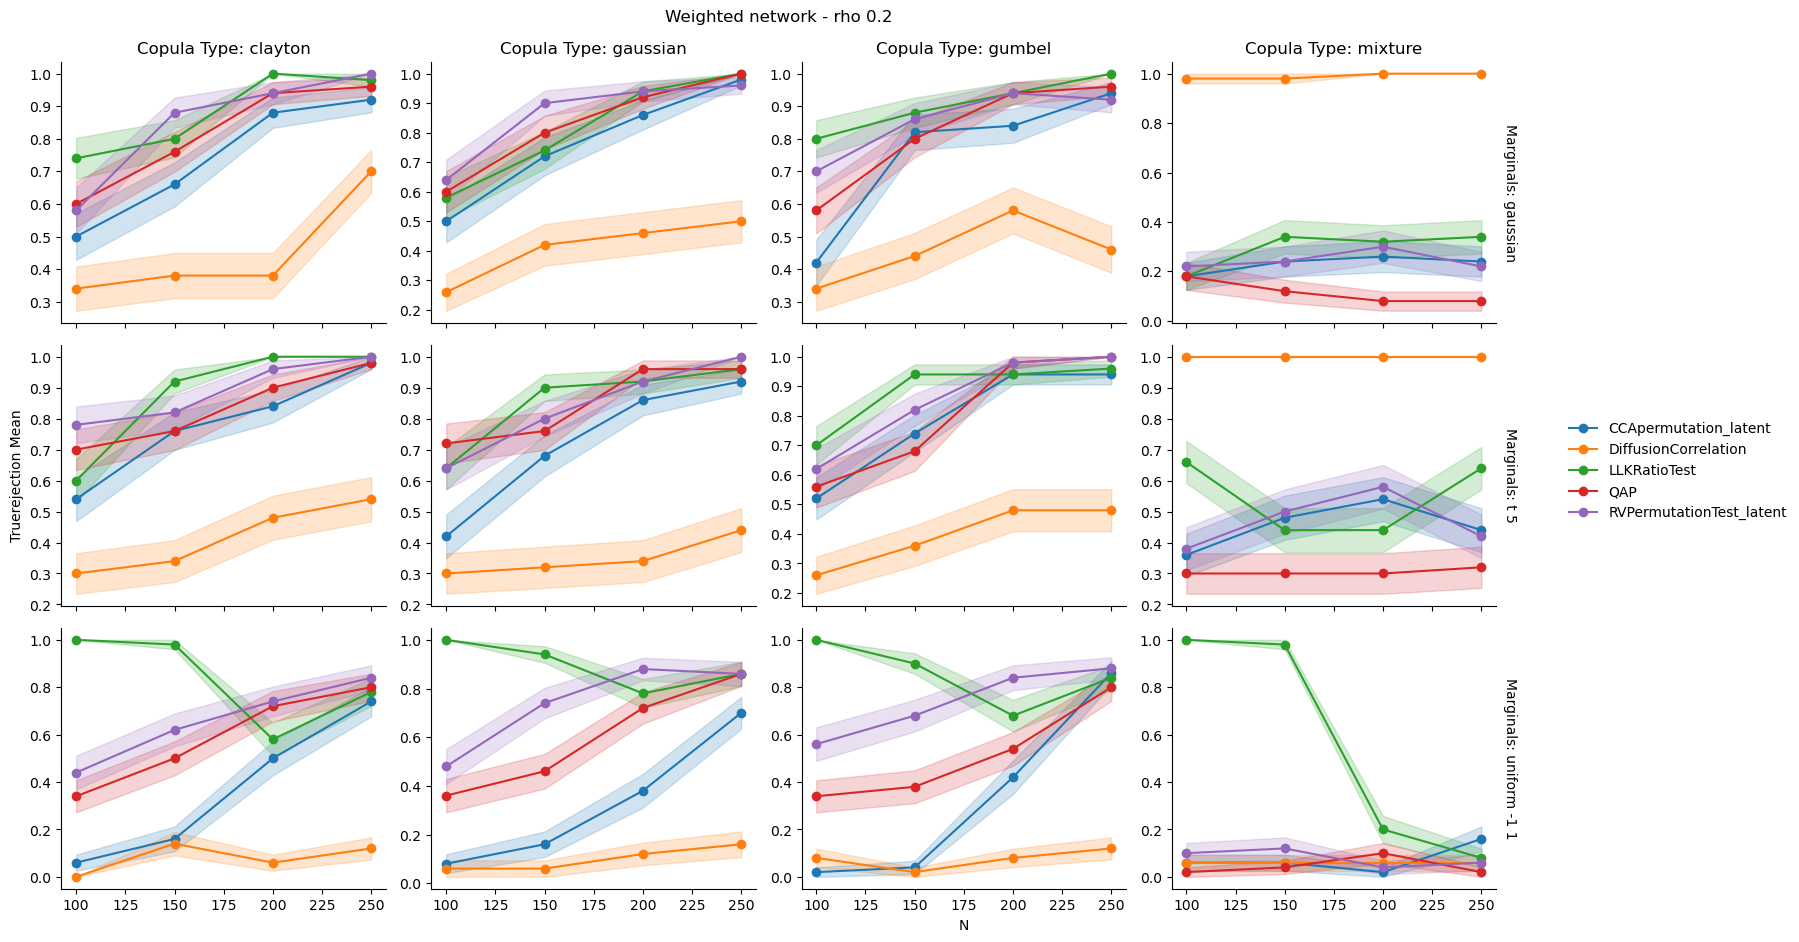

In [21]:
plot_grid(
    grouped_stats=agg_alt_02_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
)

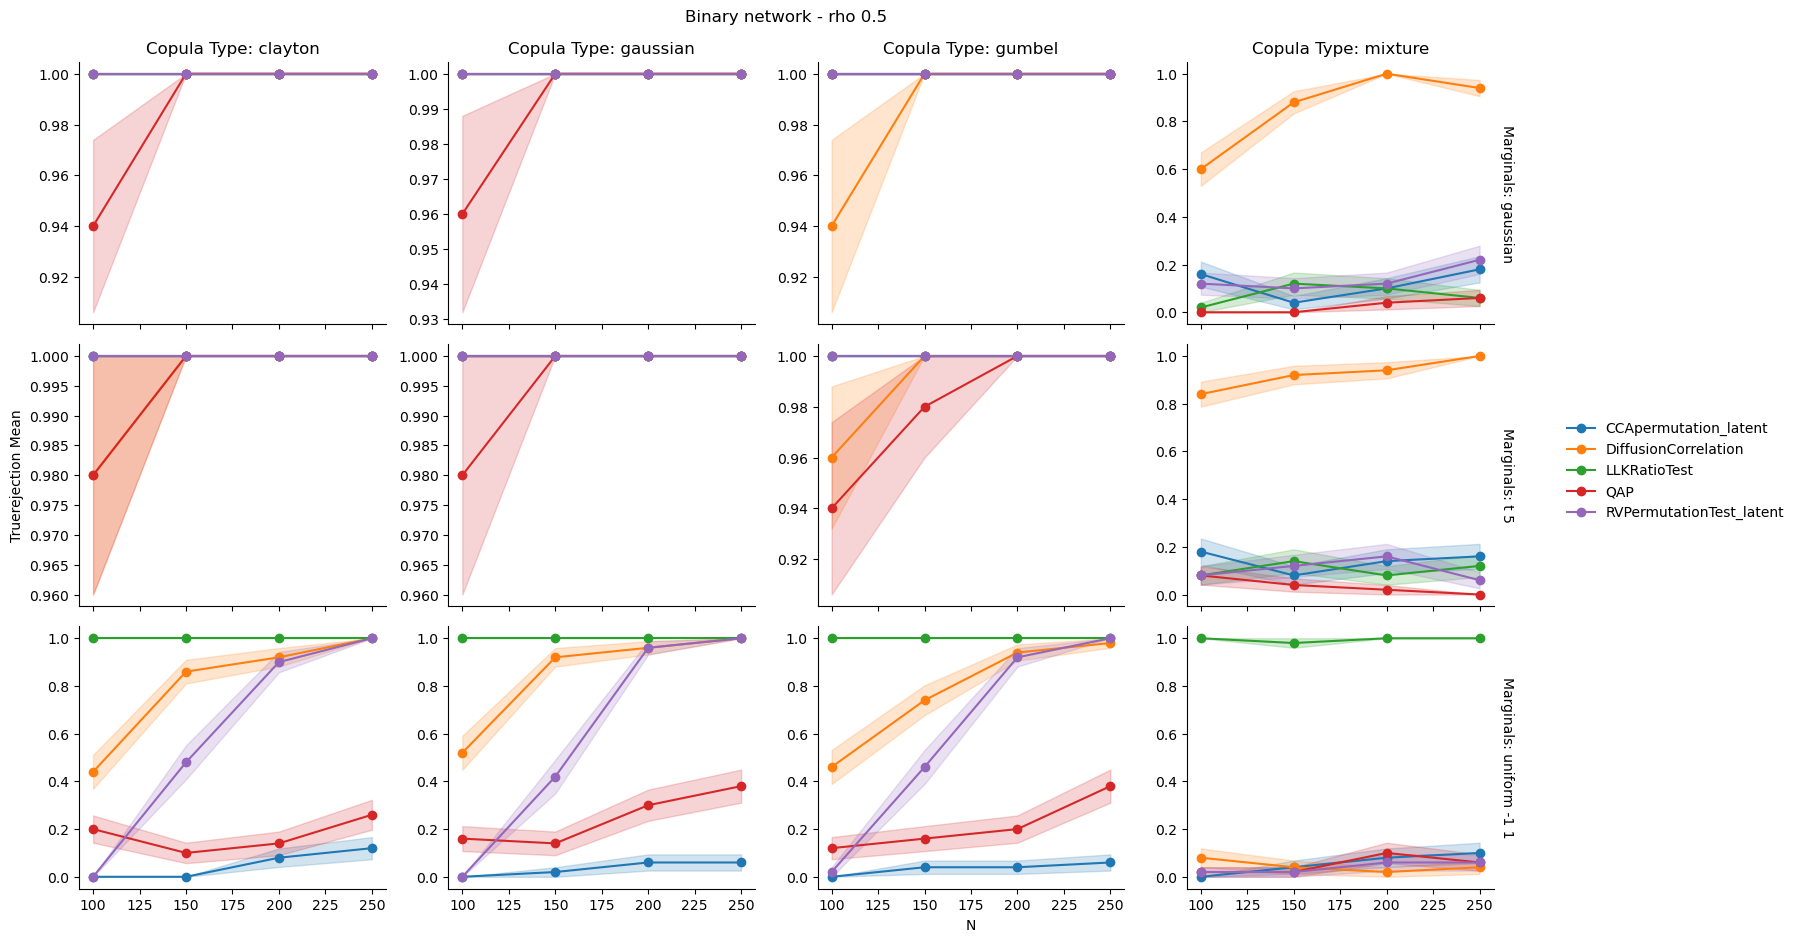

In [22]:
plot_grid(
    grouped_stats=agg_alt_05_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.5",
)


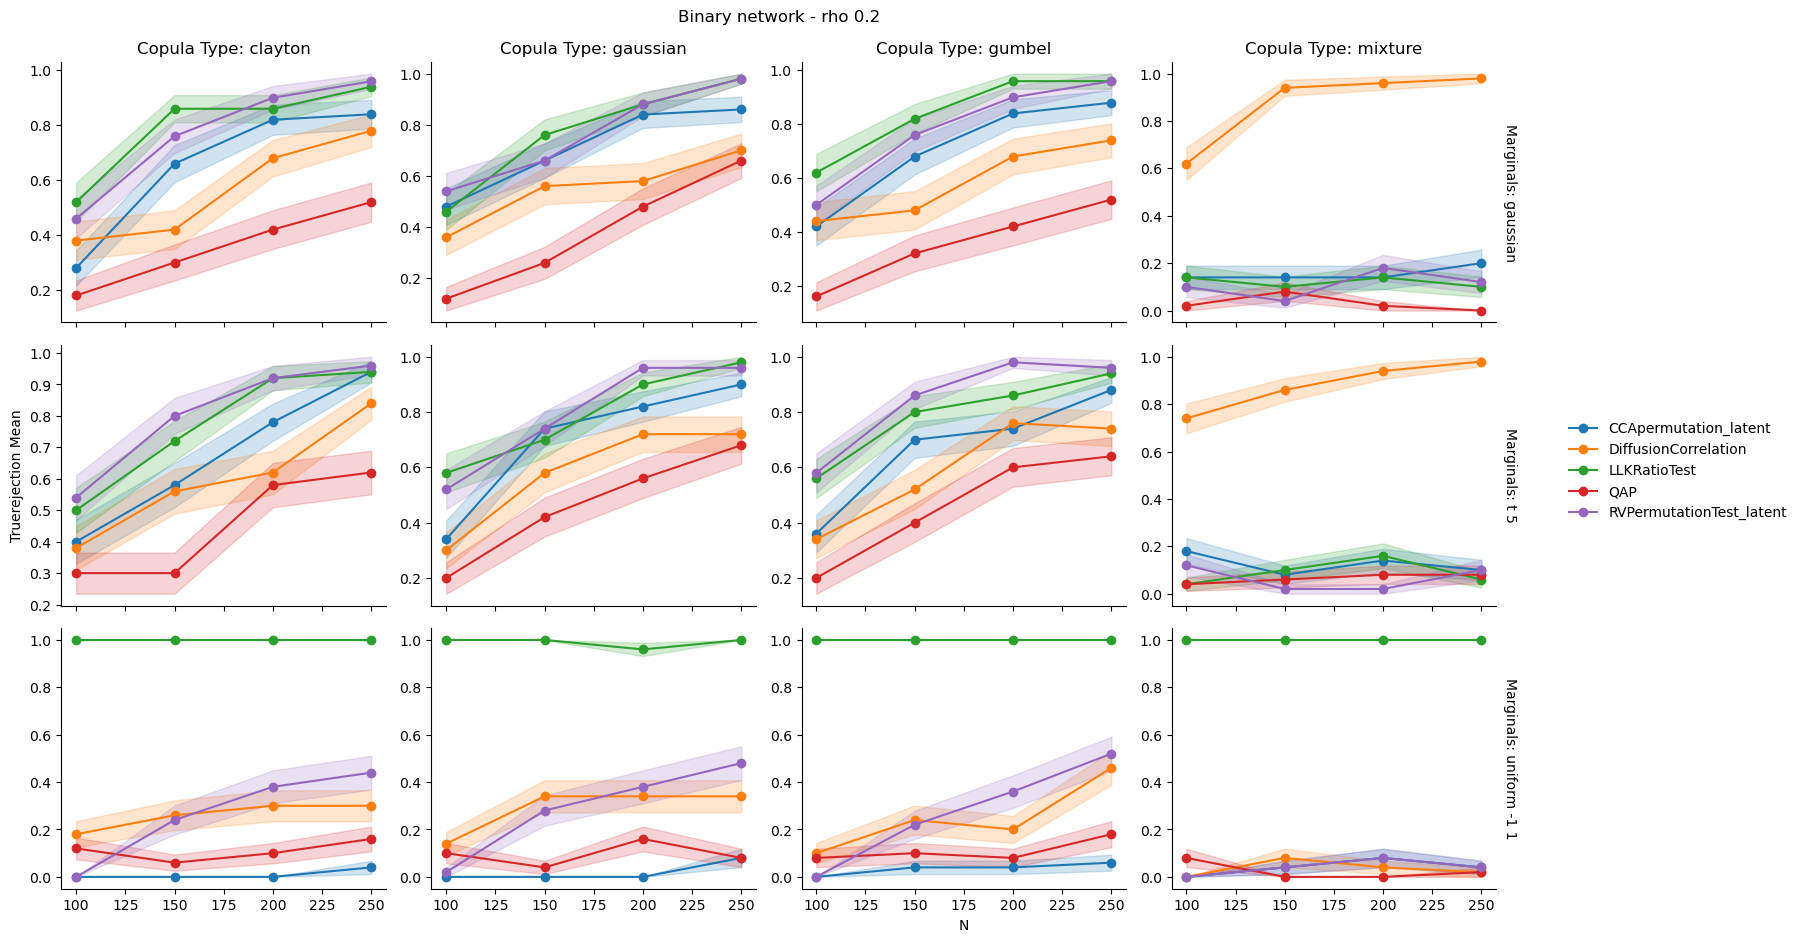

In [ ]:
plot_grid(
    grouped_stats=agg_alt_02_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="TrueRejection_mean",
    factors=["method", "copula_type", "marginals"],
    height=3,
    se_bands="TrueRejection_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
)